In [1]:
import torch
import torch.nn as nn
import os
import random
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from torchvision.utils import make_grid
import matplotlib.pyplot as plt

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
def load_texts(directory="."):
    text = ""
    for filename in os.listdir(directory):
        if filename.endswith(".txt"):
            with open(filename, 'r', encoding='utf-8') as f:
                text += f.read() + "\n"
    return text

raw_text = load_texts()
print(f"Total chars: {len(raw_text)}")

Total chars: 1317362


In [ ]:
chars = sorted(list(set(raw_text)))
char_to_int = {c: i for i, c in enumerate(chars)}
int_to_char = {i: c for i, c in enumerate(chars)}
vocab_size = len(chars)

print(f"Unique chars: {vocab_size}")

Unique chars: 185


In [ ]:
class TextGeneratorRNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, n_layers=2):
        super(TextGeneratorRNN, self).__init__()
        self.hidden_size = hidden_size
        self.n_layers = n_layers

        self.embedding = nn.Embedding(input_size, hidden_size)
        self.lstm = nn.LSTM(hidden_size, hidden_size, n_layers, batch_first=True, dropout=0.2)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x, hidden):
        embedded = self.embedding(x)
        output, hidden = self.lstm(embedded, hidden)

        output = output.contiguous().view(-1, self.hidden_size)
        output = self.fc(output)
        return output, hidden

    def init_hidden(self, batch_size):
        weight = next(self.parameters()).data
        return (weight.new(self.n_layers, batch_size, self.hidden_size).zero_(),
                weight.new(self.n_layers, batch_size, self.hidden_size).zero_())

In [ ]:
SEQ_LEN = 100
BATCH_SIZE = 64
HIDDEN_DIM = 256
LR = 0.001
EPOCHS = 100

model_task1 = TextGeneratorRNN(vocab_size, HIDDEN_DIM, vocab_size).to(device)
optimizer = torch.optim.Adam(model_task1.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss()

In [ ]:
def get_batch(text_data, seq_len, batch_size):
    inputs = []
    targets = []
    for _ in range(batch_size):
        start_idx = random.randint(0, len(text_data) - seq_len - 1)
        chunk = text_data[start_idx : start_idx + seq_len + 1]
        input_seq = [char_to_int[c] for c in chunk[:-1]]
        target_seq = [char_to_int[c] for c in chunk[1:]]
        inputs.append(input_seq)
        targets.append(target_seq)
    return torch.tensor(inputs).to(device), torch.tensor(targets).to(device)

In [ ]:
model_task1.train()

for epoch in range(EPOCHS):
    h = model_task1.init_hidden(BATCH_SIZE)

    epoch_loss = 0
    epoch_acc = 0
    steps_per_epoch = 100

    for step in range(steps_per_epoch):
        inputs, targets = get_batch(raw_text, SEQ_LEN, BATCH_SIZE)

        h = tuple([each.data for each in h])
        model_task1.zero_grad()
        output, h = model_task1(inputs, h)
        flat_targets = targets.view(-1)
        loss = criterion(output, flat_targets)

        predictions = torch.argmax(output, dim=1)
        correct = (predictions == flat_targets).float()
        accuracy = correct.mean().item()
        loss.backward()
        nn.utils.clip_grad_norm_(model_task1.parameters(), 5)
        optimizer.step()

        epoch_loss += loss.item()
        epoch_acc += accuracy

    avg_loss = epoch_loss / steps_per_epoch
    avg_acc = epoch_acc / steps_per_epoch

    print(f"Epoch: {epoch+1}/{EPOCHS} - loss: {avg_loss:.5f}; accuracy: {avg_acc*100:.2f}%")

Epoch: 1/100 - loss: 3.42114; accuracy: 18.58%
Epoch: 2/100 - loss: 2.74852; accuracy: 26.16%
Epoch: 3/100 - loss: 2.51600; accuracy: 30.08%
Epoch: 4/100 - loss: 2.39235; accuracy: 32.90%
Epoch: 5/100 - loss: 2.30677; accuracy: 34.98%
Epoch: 6/100 - loss: 2.24491; accuracy: 36.59%
Epoch: 7/100 - loss: 2.18523; accuracy: 38.08%
Epoch: 8/100 - loss: 2.12892; accuracy: 39.48%
Epoch: 9/100 - loss: 2.09379; accuracy: 40.34%
Epoch: 10/100 - loss: 2.05560; accuracy: 41.28%
Epoch: 11/100 - loss: 2.02848; accuracy: 42.01%
Epoch: 12/100 - loss: 2.00202; accuracy: 42.62%
Epoch: 13/100 - loss: 1.98578; accuracy: 43.05%
Epoch: 14/100 - loss: 1.95344; accuracy: 43.81%
Epoch: 15/100 - loss: 1.93707; accuracy: 44.07%
Epoch: 16/100 - loss: 1.91665; accuracy: 44.59%
Epoch: 17/100 - loss: 1.91286; accuracy: 44.62%
Epoch: 18/100 - loss: 1.88991; accuracy: 45.25%
Epoch: 19/100 - loss: 1.87898; accuracy: 45.53%
Epoch: 20/100 - loss: 1.85997; accuracy: 45.90%
Epoch: 21/100 - loss: 1.84722; accuracy: 46.26%
E

In [ ]:
def generate_text(model, start_str="Лис", len_out=100, temperature=0.8):
    model.eval()
    chars_idx = [char_to_int.get(c, 0) for c in start_str]
    input_seq = torch.tensor(chars_idx).unsqueeze(0).to(device)

    h = model.init_hidden(1)
    predicted = start_str

    for _ in range(len_out):
        output, h = model(input_seq, h)

        prob = torch.nn.functional.softmax(output[-1] / temperature, dim=0).data
        char_idx = torch.multinomial(prob, 1).item()
        char = int_to_char[char_idx]
        predicted += char
        input_seq = torch.tensor([[char_idx]]).to(device)

    return predicted

print(generate_text(model_task1, len_out=300))

Лис, Ві* приходили щось в ній для мене добровіше, це в соціалістичного справах історії белицької поетичні мотивнем і провінції. Закридження руського суспільності І. Франка (1841—1891), добре просвітня Ромео і р. 1888—[18147 ученкою, як до Мудеш і помилки чужить про На- скоронати, що стоїть також говори


In [ ]:
BATCH_SIZE = 128
LEARNING_RATE = 1e-3
NUM_EPOCHS = 100
Z_DIM = 40
INPUT_DIM = 784
HIDDEN_DIM = 400

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
])

train_dataset = datasets.FashionMNIST(root='./data', train=True, transform=transform, download=True)
train_loader = DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True)

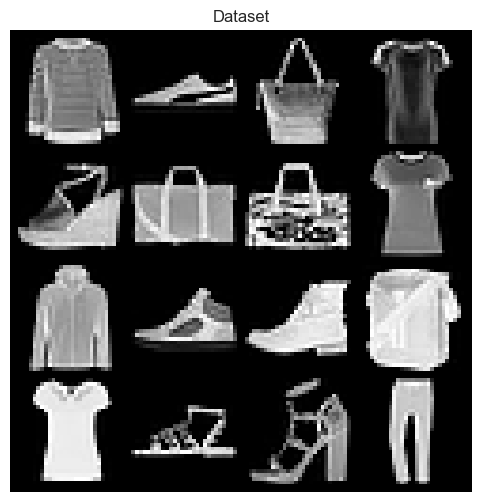

In [ ]:
def show_images(images, title="Dataset"):
    images = images.detach().cpu()
    grid_img = make_grid(images[:16], nrow=4)
    plt.figure(figsize=(6, 6))
    plt.imshow(grid_img.permute(1, 2, 0))
    plt.title(title)
    plt.axis('off')
    plt.show()

sample_batch, _ = next(iter(train_loader))
show_images(sample_batch)

In [ ]:
class VAE(nn.Module):
    def __init__(self, input_dim=INPUT_DIM, hidden_dim=HIDDEN_DIM, z_dim=Z_DIM):
        super(VAE, self).__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU()
        )

        self.fc_mu = nn.Linear(hidden_dim // 2, z_dim)
        self.fc_log_var = nn.Linear(hidden_dim // 2, z_dim)

        self.decoder = nn.Sequential(
            nn.Linear(z_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim),
            nn.Sigmoid()
        )

    def reparameterize(self, mu, log_var):
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        x = x.view(-1, INPUT_DIM)
        hidden = self.encoder(x)
        mu = self.fc_mu(hidden)
        log_var = self.fc_log_var(hidden)
        z = self.reparameterize(mu, log_var)
        reconstruction = self.decoder(z)

        return reconstruction.view(-1, 1, 28, 28), mu, log_var

In [ ]:
model_task2 = VAE().to(device)
optimizer = optim.Adam(model_task2.parameters(), lr=LEARNING_RATE)

In [ ]:
def vae_loss_fn(reconstructed_x, x, mu, log_var):
    BCE = nn.functional.binary_cross_entropy(reconstructed_x, x, reduction='sum')
    KLD = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())
    return BCE + KLD

In [ ]:
for epoch in range(NUM_EPOCHS):
    model_task2.train()
    train_loss = 0

    for batch_idx, (data, _) in enumerate(train_loader):
        data = data.to(device)
        reconstruction, mu, log_var = model_task2(data)
        loss = vae_loss_fn(reconstruction, data, mu, log_var)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        
    avg_loss = train_loss / len(train_loader.dataset)
    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] - loss: {avg_loss:.4f}")

Epoch [1/100] - loss: 295.8912
Epoch [2/100] - loss: 257.0122
Epoch [3/100] - loss: 250.5036
Epoch [4/100] - loss: 247.3372
Epoch [5/100] - loss: 245.2518
Epoch [6/100] - loss: 244.0152
Epoch [7/100] - loss: 243.0066
Epoch [8/100] - loss: 242.2121
Epoch [9/100] - loss: 241.6381
Epoch [10/100] - loss: 241.0897
Epoch [11/100] - loss: 240.5905
Epoch [12/100] - loss: 240.1374
Epoch [13/100] - loss: 239.8393
Epoch [14/100] - loss: 239.4556
Epoch [15/100] - loss: 239.1712
Epoch [16/100] - loss: 239.0016
Epoch [17/100] - loss: 238.7809
Epoch [18/100] - loss: 238.5685
Epoch [19/100] - loss: 238.4156
Epoch [20/100] - loss: 238.3142
Epoch [21/100] - loss: 238.1131
Epoch [22/100] - loss: 237.9574
Epoch [23/100] - loss: 237.8901
Epoch [24/100] - loss: 237.7657
Epoch [25/100] - loss: 237.6538
Epoch [26/100] - loss: 237.6036
Epoch [27/100] - loss: 237.4454
Epoch [28/100] - loss: 237.3929
Epoch [29/100] - loss: 237.3132
Epoch [30/100] - loss: 237.2420
Epoch [31/100] - loss: 237.1822
Epoch [32/100] - 

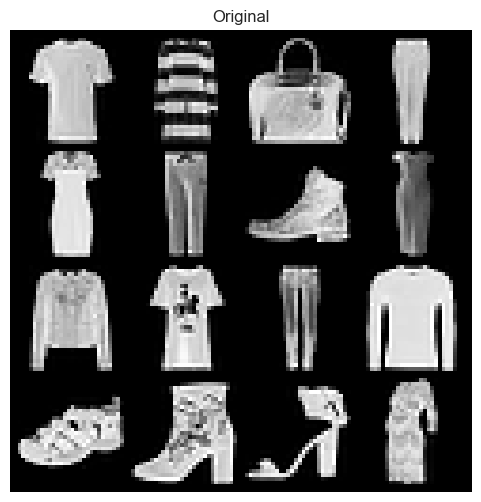

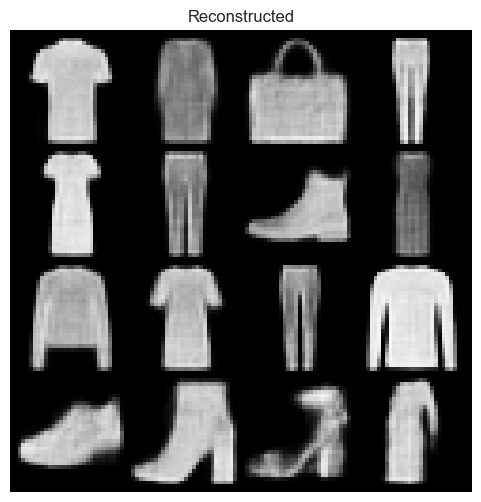

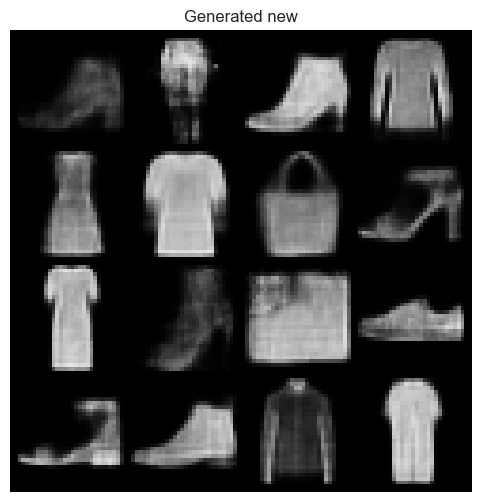

In [ ]:
model_task2.eval()

with torch.no_grad():
    test_batch, _ = next(iter(train_loader))
    test_batch = test_batch.to(device)
    recon_batch, _, _ = model_task2(test_batch)

    show_images(test_batch, title="Original")
    show_images(recon_batch, title="Reconstructed")
    noise = torch.randn(16, Z_DIM).to(device)
    generated_images = model_task2.decoder(noise).view(-1, 1, 28, 28)
    show_images(generated_images, title="Generated new")

In [ ]:
!pip install transformers diffusers accelerate scipy safetensors sentencepiece hf_xet

In [1]:
from transformers import pipeline
from diffusers import StableDiffusionPipeline

In [ ]:
# Zero-Shot Classification
classifier = pipeline("zero-shot-classification", model="MoritzLaurer/mDeBERTa-v3-base-mnli-xnli", device=0)

text_to_classify = "Суперкомп’ютер створив найреалістичніший віртуальний мозок у світі"
candidate_labels = ["спорт", "економіка", "політика", "наука"]
result = classifier(text_to_classify, candidate_labels, multi_label=False)

print(f"Result: {result['labels'][0]}")


config.json: 0.00B [00:00, ?B/s]

C:\Users\acer\AppData\Local\Programs\Python\Python310\lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\acer\.cache\huggingface\hub\models--MoritzLaurer--mDeBERTa-v3-base-mnli-xnli. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


model.safetensors:   0%|          | 0.00/558M [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spm.model:   0%|          | 0.00/4.31M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/16.3M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/23.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/286 [00:00<?, ?B/s]

Device set to use cuda:0


Result: наука


In [4]:
# Translation
translator = pipeline("translation", model="Helsinki-NLP/opus-mt-uk-en", device=0)

ukr_text = """
Канадські вчені виявили, що старіння має «точку неповернення» приблизно у 75 років.
"""

translation = translator(ukr_text, max_length=400)
print(f"Translation: {translation[0]['translation_text']}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/305M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/42.0 [00:00<?, ?B/s]

...

source.spm:   0%|          | 0.00/1.01M [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/809k [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/models/marian/tokenization_marian.py:175: UserWarning: Recommended: pip install sacremoses.
  warnings.warn("Recommended: pip install sacremoses.")
Device set to use cpu


Translation: Canadian researchers found that aging has a slight neuterism at about 75 years of age.


In [ ]:
model_id = "dreamlike-art/dreamlike-photoreal-2.0"
pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float32,
    safety_checker=None,
    requires_safety_checker=False
)

pipe = pipe.to(device)

pipe = pipe.to(device)

Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

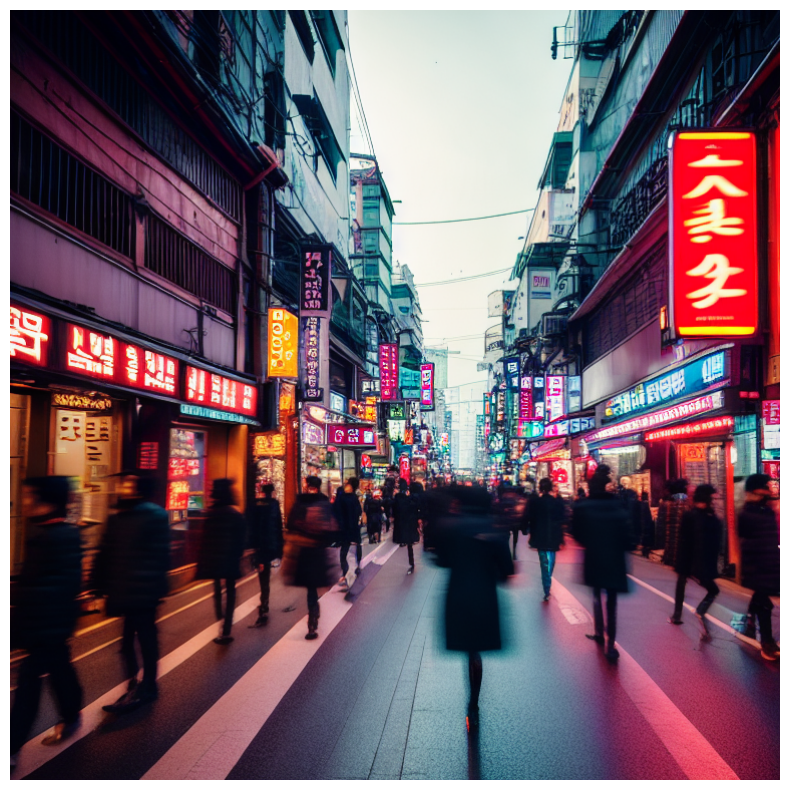

In [ ]:
prompt = "night shot of a bustling Seoul street, photorealistic, 8k"

negative_prompt = "cartoon, drawing, low quality, watermark"

image = pipe(prompt, negative_prompt=negative_prompt).images[0]

plt.figure(figsize=(10, 10))
plt.imshow(image)
plt.axis("off")
plt.show()

image.save("task3_3.png")